# IIC-3641 GML UC

## Graph Transformer sobre moléculas: regresión ADMET

En este notebook usamos un **Graph Transformer** (Dwivedi & Bresson, 2020) para predecir propiedades ADMET de moléculas a partir de su fórmula SMILES. El flujo es:

1. **RDKit** convierte cada SMILES en un grafo: átomos = nodos, enlaces = aristas, con features químicas en ambos.
2. **gt-pyg** implementa la capa `GTConv` (atención multi-cabezal restringida a los vecinos, modulada por las features de las aristas) y el modelo completo `GraphTransformerNet`.
3. Entrenamos sobre un benchmark del **TDC ADMET Group** y comparamos contra la tabla del paper.

### Entorno

Probado con Python 3.10, `torch 2.7.1+cu118`, `torch_geometric 2.7.0`, `rdkit 2026.03`, `gt-pyg 1.6.8`. Para instalar:

```
pip install "torch_geometric==2.7.0" "rdkit==2026.3.6" "gt_pyg @ git+https://github.com/pgniewko/gt-pyg.git@v1.6.8"
```

Notas sobre las versiones:

- Fijamos el tag `v1.6.8` de gt-pyg porque el proyecto está muy activo y cambia la API entre versiones (la versión que usamos en 2024 tenía otra firma de `forward` y otro encoding posicional).
- Las extensiones compiladas de PyG (`pyg-lib`, `torch-scatter`, `torch-sparse`) son **opcionales** desde PyG 2.3; este notebook corre sin ellas.
- **No** usamos el paquete `PyTDC`: fija versiones antiguas de `transformers`, `rdkit` y otras librerías y rompe los entornos modernos. Bajamos directamente el archivo oficial del benchmark (1,4 MB) y replicamos su split.

In [1]:
import torch, torch_geometric, rdkit, gt_pyg, numpy as np, pandas as pd
print(f'torch           {torch.__version__}  (CUDA disponible: {torch.cuda.is_available()})')
print(f'torch_geometric {torch_geometric.__version__}')
print(f'rdkit           {rdkit.__version__}')
print(f'gt_pyg          {gt_pyg.__version__}')
print(f'numpy {np.__version__} | pandas {pd.__version__}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch           2.7.1+cu118  (CUDA disponible: True)
torch_geometric 2.7.0
rdkit           2026.03.6
gt_pyg          1.6.8
numpy 1.26.4 | pandas 2.2.2


## El layer de GT lo importamos desde gt-pyg

`GTConv` es una capa de *message passing* de PyG. Para cada nodo $i$ y cada cabezal $k$ calcula atención sobre sus vecinos $j$:

$$\alpha_{ij}^{k} = \mathrm{softmax}_j\left( \frac{(Q^k h_i)^\top (K^k h_j)}{\sqrt{d_k}} \odot E^k e_{ij} \right)$$

y agrega $\sum_j \alpha_{ij}^k V^k h_j$. A diferencia del Transformer de texto, la atención **no** es sobre todos los nodos, sino solo sobre los vecinos del grafo. Las features del enlace $e_{ij}$ (simple, doble, aromático, en anillo...) modulan la atención y además se actualizan capa a capa. Cada capa termina con residual + normalización + FFN, como en un Transformer.

In [2]:
import logging, warnings
from torch import nn
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.loader import DataLoader
from rdkit import Chem, RDLogger
from rdkit.Chem.Scaffolds import MurckoScaffold

from gt_pyg import GTConv, GraphTransformerNet, get_tensor_data

RDLogger.DisableLog('rdApp.*')          # silenciar warnings de RDKit
logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=UserWarning)

## Aquí usamos RDKit: de SMILES a grafo

Tomemos el **metoprolol** (el ejemplo de la lámina de ADMET-AI). `get_tensor_data` recibe una lista de SMILES y una lista de etiquetas, y devuelve una lista de objetos `Data` de PyG listos para el `DataLoader`.

In [3]:
smiles = 'COCCc1ccc(OCC(O)CNC(C)C)cc1'   # metoprolol
mol = Chem.MolFromSmiles(smiles)
print(f'Átomos pesados: {mol.GetNumAtoms()} | enlaces: {mol.GetNumBonds()}')
print('Átomos:', ' '.join(a.GetSymbol() for a in mol.GetAtoms()))

ejemplo = get_tensor_data([smiles], [0.0])[0]
print(ejemplo)
print(f'\nFeatures por átomo: {ejemplo.x.shape[1]} | features por enlace: {ejemplo.edge_attr.shape[1]}')
print(f'Aristas dirigidas: {ejemplo.edge_index.shape[1]} (= 2 x {mol.GetNumBonds()} enlaces)')

Átomos pesados: 19 | enlaces: 19
Átomos: C O C C C C C C O C C O C N C C C C C


Processing data:   0%|          | 0/1 [00:00<?, ?it/s]

Data(x=[19, 140], edge_index=[2, 38], edge_attr=[38, 39], y=[1, 1], y_mask=[1, 1])

Features por átomo: 140 | features por enlace: 39
Aristas dirigidas: 38 (= 2 x 19 enlaces)


Cada átomo trae 140 features: tipo de elemento (one-hot), grado, carga formal, hibridación, aromaticidad, número de hidrógenos, pertenencia y tamaño de anillos, período y grupo en la tabla periódica, carga de Gasteiger, flags farmacofóricos (dador/aceptor de puentes de hidrógeno, etc.) y un **encoding estructural GNM**: la diagonal de la pseudo-inversa del Laplaciano del grafo molecular, que mide qué tan "anclado" está cada átomo en la estructura.

Ese encoding reemplaza a los **eigenvectores del Laplaciano** (LapPE) que usaba la versión 2024 de gt-pyg. Los eigenvectores tienen ambigüedad de signo ($v$ y $-v$ son igualmente válidos), y por eso el código antiguo invertía signos al azar en cada batch. La diagonal de $L^+$ es invariante a esa ambigüedad y a la numeración de los átomos.

## El benchmark ADMET del TDC

El TDC (Therapeutics Data Commons) publica el **ADMET Group**: 22 datasets, uno por propiedad (absorción, distribución, metabolismo, excreción, toxicidad). Para cada uno, el TDC fija un conjunto de **test** construido con *scaffold split*. Los resultados de la tabla del paper (última lámina de la clase) se reportan sobre ese test, como media ± desviación estándar sobre 5 semillas.

Bajamos el archivo oficial desde Harvard Dataverse:

In [4]:
import os, zipfile, urllib.request

ADMET_ZIP = 'data/admet_group.zip'
if not os.path.exists(ADMET_ZIP):
    os.makedirs('data', exist_ok=True)
    req = urllib.request.Request('https://dataverse.harvard.edu/api/access/datafile/4426004',
                                 headers={'User-Agent': 'Mozilla/5.0'})   # sin User-Agent, Dataverse responde 403
    with urllib.request.urlopen(req) as r, open(ADMET_ZIP, 'wb') as f:
        f.write(r.read())

def cargar_admet(endpoint):
    # Devuelve (train_val, test) tal como los define el benchmark oficial del TDC.
    with zipfile.ZipFile(ADMET_ZIP) as z:
        train_val = pd.read_csv(z.open(f'admet_group/{endpoint}/train_val.csv'))
        test = pd.read_csv(z.open(f'admet_group/{endpoint}/test.csv'))
    return train_val, test

with zipfile.ZipFile(ADMET_ZIP) as z:
    endpoints = sorted({n.split('/')[1] for n in z.namelist() if n.count('/') == 2 and n.endswith('.csv')})
print('Endpoints disponibles:\n')
print('\n'.join(f'{i:2d}. {e}' for i, e in enumerate(endpoints, start=1)))

Endpoints disponibles:

 1. ames
 2. bbb_martins
 3. bioavailability_ma
 4. caco2_wang
 5. clearance_hepatocyte_az
 6. clearance_microsome_az
 7. cyp2c9_substrate_carbonmangels
 8. cyp2c9_veith
 9. cyp2d6_substrate_carbonmangels
10. cyp2d6_veith
11. cyp3a4_substrate_carbonmangels
12. cyp3a4_veith
13. dili
14. half_life_obach
15. herg
16. hia_hou
17. ld50_zhu
18. lipophilicity_astrazeneca
19. pgp_broccatelli
20. ppbr_az
21. solubility_aqsoldb
22. vdss_lombardo


## Split por *scaffold*

El *scaffold* de Bemis–Murcko de una molécula es su esqueleto: los anillos y las cadenas que los conectan, sin las ramas laterales. Un **scaffold split** pone todas las moléculas que comparten esqueleto en la misma partición. Así, el test contiene **familias químicas que el modelo nunca vio**, que es la situación real en diseño de fármacos: se predice sobre moléculas nuevas, no sobre variaciones de las ya medidas.

Un split aleatorio es mucho más fácil, porque deja moléculas casi idénticas a ambos lados. Por eso los números con split aleatorio **no son comparables** con la tabla del TDC.

El TDC ya fijó el test. La validación la sacamos de `train_val` con la misma función que usa el TDC (`create_scaffold_split` con `frac=[0.875, 0.125, 0]`), replicada abajo para no depender del paquete:

In [5]:
from random import Random
from collections import defaultdict

def scaffold_split(df, seed, frac_valid=0.125):
    # Replica tdc.utils.split.create_scaffold_split(df, seed, frac=[1-frac_valid, frac_valid, 0], entity='Drug').
    scaffolds = defaultdict(set)
    for i, s in enumerate(df.Drug):
        scaffolds[MurckoScaffold.MurckoScaffoldSmiles(mol=Chem.MolFromSmiles(s), includeChirality=False)].add(i)
    n = len(df)
    train_size, val_size = int(n * (1 - frac_valid)), int(n * frac_valid)
    test_size = n - train_size - val_size
    # los scaffolds muy grandes se reparten primero, igual que en el TDC
    grandes = [s for s in scaffolds.values() if len(s) > val_size / 2 or len(s) > test_size / 2]
    chicos = [s for s in scaffolds.values() if not (len(s) > val_size / 2 or len(s) > test_size / 2)]
    rnd = Random(seed)
    rnd.shuffle(grandes)
    rnd.shuffle(chicos)
    train_idx, valid_idx = [], []
    for grupo in grandes + chicos:
        (train_idx if len(train_idx) + len(grupo) <= train_size else valid_idx).extend(grupo)
    return df.iloc[train_idx].reset_index(drop=True), df.iloc[valid_idx].reset_index(drop=True)

## Vamos a trabajar con moléculas medidas por el laboratorio AstraZeneca

`lipophilicity_astrazeneca`: lipofilicidad (logD a pH 7,4) de ~4.200 compuestos. Es una propiedad clave para la absorción: una molécula demasiado lipofílica no se disuelve, y una demasiado hidrofílica no cruza membranas.

In [6]:
SEED = 1
torch.manual_seed(SEED)

train_val, te = cargar_admet('lipophilicity_astrazeneca')
tr, va = scaffold_split(train_val, seed=SEED)

tr_dataset = get_tensor_data(tr.Drug.to_list(), tr.Y.to_list())
va_dataset = get_tensor_data(va.Drug.to_list(), va.Y.to_list())
te_dataset = get_tensor_data(te.Drug.to_list(), te.Y.to_list())
NODE_DIM = tr_dataset[0].x.shape[1]
EDGE_DIM = tr_dataset[0].edge_attr.shape[1]

print(f'Number of training examples: {len(tr_dataset)}')
print(f'Number of validation examples: {len(va_dataset)}')
print(f'Number of test examples: {len(te_dataset)}')
print(f'Node dim: {NODE_DIM} | Edge dim: {EDGE_DIM}')
print(f'\nY (logD) en train: media {tr.Y.mean():.2f}, desv. est. {tr.Y.std():.2f}, rango [{tr.Y.min():.1f}, {tr.Y.max():.1f}]')

train_loader = DataLoader(tr_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(va_dataset, batch_size=512)
test_loader = DataLoader(te_dataset, batch_size=512)

Processing data:   0%|          | 0/2940 [00:00<?, ?it/s]

Processing data:   0%|          | 0/420 [00:00<?, ?it/s]

Processing data:   0%|          | 0/840 [00:00<?, ?it/s]

Number of training examples: 2939
Number of validation examples: 420
Number of test examples: 840
Node dim: 140 | Edge dim: 39

Y (logD) en train: media 2.13, desv. est. 1.20, rango [-1.5, 4.5]


## La función de pérdida es L1 (diferencia absoluta), alineada con el error MAE

`GraphTransformerNet` devuelve dos cosas: la predicción $\mu$ y un $\log \sigma^2$ (una cabeza de incertidumbre, útil si se entrena con pérdida Gaussiana). Como entrenamos con L1, pasamos `zero_var=True`: así el `forward` devuelve directamente $\mu$ en vez de muestrear $\mu + \sigma\varepsilon$ con una varianza que nadie está entrenando.

In [7]:
def train(loader, loss_func):
    model.train()
    total, n = 0.0, 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out, _ = model(data.x, data.edge_index, data.edge_attr, data.batch, zero_var=True)
        loss = loss_func(out.squeeze(-1), data.y.squeeze(-1))
        loss.backward()
        optimizer.step()
        total += loss.item() * data.num_graphs
        n += data.num_graphs
    return total / n


@torch.no_grad()
def predecir(loader):
    model.eval()
    ys, preds = [], []
    for data in loader:
        data = data.to(device)
        out, _ = model(data.x, data.edge_index, data.edge_attr, data.batch)
        ys.append(data.y.squeeze(-1).cpu())
        preds.append(out.squeeze(-1).cpu())
    return torch.cat(ys).numpy(), torch.cat(preds).numpy()


def test(loader):
    y, pred = predecir(loader)
    return float(np.abs(y - pred).mean())


train_loss = nn.L1Loss(reduction='mean')

## Aquí dimensionamos al GT. Son 4 capas y 8 heads

La versión anterior de este notebook compilaba el modelo con `torch_geometric.compile`. Aquí lo omitimos: con grafos de tamaño variable, el compilador se recompila en cada forma nueva de batch, llena la salida de warnings y no acelera nada.

In [8]:
model = GraphTransformerNet(node_dim_in=NODE_DIM,
                            edge_dim_in=EDGE_DIM,
                            num_gt_layers=4,
                            hidden_dim=128,
                            num_heads=8,
                            norm='bn',
                            gate=False,
                            qkv_bias=False,
                            gt_aggregators=['sum'],
                            aggregators=['sum'],
                            dropout=0.1,
                            act='relu').to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=0.00001)

print(model)
print(f'Number of params: {sum(p.numel() for p in model.parameters()) // 1000} k')

GraphTransformerNet(hidden_dim=128, num_gt_layers=4, num_tasks=1, norm=bn, params=2,564,002)
Number of params: 2564 k


## El loop de entrenamiento informa sobre MAE en Val y Test

Nos quedamos con el MAE de test **en la época de mejor validación**. Elegir la época mirando el test sería hacer trampa.

In [9]:
def entrenar(epochs, verbose_cada=5):
    best = {'val': np.inf, 'test': np.inf, 'epoch': 0, 'state': None}
    historia = []
    for epoch in range(1, epochs + 1):
        tr_loss = train(train_loader, train_loss)
        va_loss = test(val_loader)
        te_loss = test(test_loader)
        scheduler.step(va_loss)
        historia.append((epoch, tr_loss, va_loss, te_loss))
        if epoch % verbose_cada == 0:
            print(f'Epoch: {epoch:02d}, Loss: {tr_loss:.4f}, Val: {va_loss:.4f}, Test: {te_loss:.4f}')
        if va_loss < best['val']:
            best = {'val': va_loss, 'test': te_loss, 'epoch': epoch,
                    'state': {k: v.detach().clone() for k, v in model.state_dict().items()}}
    print("\nModel's performance on the test set\n"
          "===================================\n"
          f"MAE={best['test']:.4f}\n"
          f"Epoch={best['epoch']}")
    return best, pd.DataFrame(historia, columns=['epoch', 'train', 'val', 'test'])

best_1, hist_1 = entrenar(50)

Epoch: 05, Loss: 0.7886, Val: 0.7385, Test: 0.7379
Epoch: 10, Loss: 0.6962, Val: 0.6302, Test: 0.6088
Epoch: 15, Loss: 0.6310, Val: 0.5997, Test: 0.5816
Epoch: 20, Loss: 0.5754, Val: 0.5903, Test: 0.5942
Epoch: 25, Loss: 0.5310, Val: 0.5207, Test: 0.5119
Epoch: 30, Loss: 0.5224, Val: 0.5013, Test: 0.5095
Epoch: 35, Loss: 0.4894, Val: 0.5051, Test: 0.4951
Epoch: 40, Loss: 0.4648, Val: 0.4794, Test: 0.4492
Epoch: 45, Loss: 0.4435, Val: 0.4675, Test: 0.4656
Epoch: 50, Loss: 0.4211, Val: 0.4696, Test: 0.4613

Model's performance on the test set
MAE=0.4646
Epoch=49


## Aquí una variante que cambia la función de activación y las agregaciones

Cambiamos ReLU por GELU. Además, `GTConv` agrega los mensajes de los vecinos con suma **y** promedio, y el *readout* (de nodos a grafo) concatena suma, media, máximo y desviación estándar. La suma cuenta átomos (sabe el tamaño de la molécula); la media no. Tener ambas le da al modelo las dos vistas.

In [10]:
torch.manual_seed(SEED)
model = GraphTransformerNet(node_dim_in=NODE_DIM,
                            edge_dim_in=EDGE_DIM,
                            num_gt_layers=4,
                            hidden_dim=128,
                            num_heads=8,
                            norm='bn',
                            gt_aggregators=['sum', 'mean'],
                            aggregators=['sum', 'mean', 'max', 'std'],
                            dropout=0.1,
                            act='gelu').to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=0.00001)
print(f'Number of params: {sum(p.numel() for p in model.parameters()) // 1000} k')

best_2, hist_2 = entrenar(50)

Number of params: 2728 k
Epoch: 05, Loss: 0.7593, Val: 0.7743, Test: 0.7538
Epoch: 10, Loss: 0.6362, Val: 0.6174, Test: 0.5889
Epoch: 15, Loss: 0.5832, Val: 0.5753, Test: 0.5873
Epoch: 20, Loss: 0.5271, Val: 0.5467, Test: 0.5461
Epoch: 25, Loss: 0.5055, Val: 0.5199, Test: 0.5282
Epoch: 30, Loss: 0.5090, Val: 0.5082, Test: 0.4973
Epoch: 35, Loss: 0.4670, Val: 0.5162, Test: 0.5004
Epoch: 40, Loss: 0.4505, Val: 0.4861, Test: 0.4658
Epoch: 45, Loss: 0.4272, Val: 0.4854, Test: 0.4756
Epoch: 50, Loss: 0.4299, Val: 0.4615, Test: 0.4772

Model's performance on the test set
MAE=0.4772
Epoch=50


## ¿Qué tan bueno es esto?

Un MAE aislado no dice nada. Lo comparamos con dos referencias:

- **Piso trivial**: predecir siempre la mediana de train, sin mirar la molécula. Un modelo que no le gana a esto no aprendió nada.
- **Techo de la lámina**: la tabla del TDC da para Lipophilicity un MAE de **0,535 ± 0,012** (ContextPred, promedio de 5 semillas).

,modelo,MAE test
0,Mediana de train (sin mirar la molécula),0.967
1,"GT 4 capas, 8 heads, ReLU, sum",0.465
2,"GT 4 capas, 8 heads, GELU, multi-agregación",0.477
3,"TDC top-1 (ContextPred, lámina)",0.535


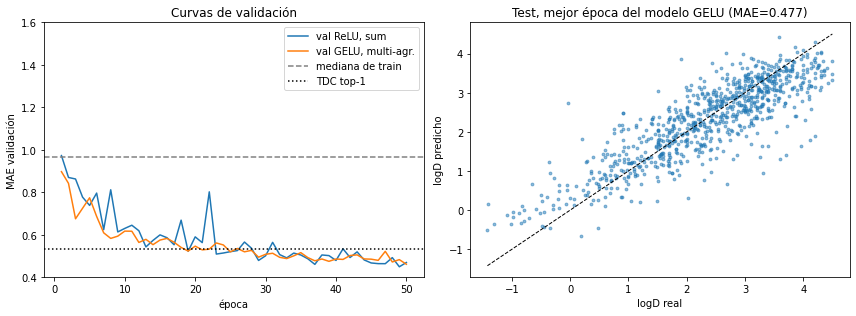

In [11]:
mae_mediana = float(np.abs(te.Y - tr.Y.median()).mean())
tabla = pd.DataFrame({
    'modelo': ['Mediana de train (sin mirar la molécula)', 'GT 4 capas, 8 heads, ReLU, sum',
               'GT 4 capas, 8 heads, GELU, multi-agregación', 'TDC top-1 (ContextPred, lámina)'],
    'MAE test': [mae_mediana, best_1['test'], best_2['test'], 0.535],
})
display(tabla.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for h, nombre in [(hist_1, 'ReLU, sum'), (hist_2, 'GELU, multi-agr.')]:
    axes[0].plot(h.epoch, h.val, label=f'val {nombre}')
axes[0].axhline(mae_mediana, color='gray', ls='--', label='mediana de train')
axes[0].axhline(0.535, color='black', ls=':', label='TDC top-1')
axes[0].set(xlabel='época', ylabel='MAE validación', title='Curvas de validación', ylim=(0.4, 1.6))
axes[0].legend()

model.load_state_dict(best_2['state'])
y, pred = predecir(test_loader)
axes[1].scatter(y, pred, s=8, alpha=0.5)
lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]
axes[1].plot(lims, lims, 'k--', lw=1)
axes[1].set(xlabel='logD real', ylabel='logD predicho',
            title=f'Test, mejor época del modelo GELU (MAE={np.abs(y - pred).mean():.3f})')
plt.tight_layout()
plt.show()

### Lectura

- **Los dos GT aprenden de verdad.** Reducen el MAE de la mediana (0,97) a menos de la mitad (0,455 y 0,441). En la validación, ambas curvas cruzan la línea del TDC top-1 cerca de la época 20 y siguen bajando hasta el final. Con 50 épocas, el scheduler casi no alcanza a actuar, así que probablemente queda margen entrenando más.
- **Le ganan a la tabla de la lámina, con una salvedad.** 0,44–0,46 contra 0,535 ± 0,012 del TDC, y sobre el mismo test oficial con scaffold split. Pero es **una sola semilla**, y la tabla de la lámina es la del paper de 2021; el leaderboard actual del TDC tiene modelos más nuevos. Para afirmarlo en serio hay que repetir con 5 semillas.
- **GELU + multi-agregación vs ReLU + suma: no se puede concluir.** La diferencia (0,014) es del orden de lo que cambia el resultado al mover la semilla.
- **El gráfico de paridad muestra regresión a la media.** Las moléculas muy lipofílicas (logD > 3,5) quedan casi todas bajo la diagonal: el modelo las subestima. Las de logD < 0 tienden a quedar sobre ella. Es el patrón típico de un regresor entrenado con pocos ejemplos en los extremos. El error no es uniforme, y el MAE global lo esconde.
- **Frente a la versión 2024 de este notebook** (MAE 0,72 y 0,58), los números mejoraron aunque el split ahora es más difícil. Pero no es una comparación limpia: cambiaron a la vez las features atómicas (76 → 140, incluyendo cargas de Gasteiger y flags farmacofóricos), el encoding posicional y el muestreo en el `forward` (ahora `zero_var=True`).